# TM10007 Machine Learning Group 10 Liver 

In [9]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [3]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm


# Statistics
from sklearn import model_selection
from sklearn import metrics
from sklearn import svm



## Data loading 

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [58]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data preprocessing

In [32]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_cleaned = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_cleaned.columns[data_cleaned.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for missing data
# Check for infinite values
print(f"Amount of infinite data: {data_cleaned.map(np.isinf).sum().sum()}")
# Check for missing values
print(f"Amount of missing data: {data_cleaned.isna().sum().sum()}")


No duplicate sample found.
No duplicate features found.
Amount of infinite data: 0
Amount of missing data: 0


## Data splitting


In [46]:
# Split the dataset in features and labels
X = data_cleaned.drop(columns=["label"])
y = data_cleaned["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")

The number of samples in the train set: 148
The number of samples in the test set: 38


## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [ ]:
# Checking the distribution of the columns of the dataset and filling in missing values
alpha = 0.05
nd_columns_train = 0
nnd_columns_train = 0

for column in X_train:
    if X_train[column].min() != X_train[column].max():
        # Perform Shapiro-Wilk test for normality
        stat, p = shapiro(X_train[column].dropna())
        # Interpret the result
        if p > alpha:
            nd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the mean of the column
                X_train[column].fillna(X_train[column].mean(), inplace=True)
        else:
            nnd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the median of the column
                X_train[column].fillna(X_train[column].median(), inplace=True)
print(f"Number of normal distributed columns in the train set: {nd_columns_train}")
print(f"Number of non-normal distributed columns in the train set: {nnd_columns_train}")
    

No duplicate sample found.
No duplicate features found.
Number of constant features: 17
Constant features names: ['PREDICT_original_tf_LBP_min_R3_P12', 'PREDICT_original_tf_LBP_max_R3_P12', 'PREDICT_original_tf_LBP_peak_R3_P12', 'PREDICT_original_tf_LBP_peak_position_R3_P12', 'PREDICT_original_tf_LBP_range_R3_P12', 'PREDICT_original_tf_LBP_max_R8_P24', 'PREDICT_original_tf_LBP_peak_R8_P24', 'PREDICT_original_tf_LBP_peak_position_R8_P24', 'PREDICT_original_tf_LBP_max_R15_P36', 'PREDICT_original_tf_LBP_peak_R15_P36', 'PREDICT_original_tf_LBP_peak_position_R15_P36', 'PREDICT_original_phasef_phasecong_min_WL3_N5', 'PREDICT_original_phasef_phasecong_peak_WL3_N5', 'PREDICT_original_phasef_phasecong_peak_position_WL3_N5', 'PREDICT_original_phasef_phasesym_min_WL3_N5', 'PREDICT_original_phasef_phasesym_peak_WL3_N5', 'PREDICT_original_phasef_phasesym_peak_position_WL3_N5']
Amount of missing data: 0

Percentage of zeros per column: 
PREDICT_original_tf_LBP_min_R8_P24                             

In [48]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

# Checking for missing data
# Print the number of missing values
print(f"Amount of missing data: {data_binary.isna().sum().sum()}")  
# Print the number of zeros per feature
zero_counts = (data_binary.drop(columns=['label']) == 0).sum()
features_with_zeros = zero_counts[zero_counts > 0]
print(f"\nPercentage of zeros per feature: \n{features_with_zeros/len(data_binary.index)*100}")

# Remove columns with =/> 10% zeros
features_to_remove_zeros = features_with_zeros[features_with_zeros > 0.1*len(data_binary.index)].index
data_binary.drop(columns=features_to_remove_zeros, inplace=True)
print(f"Removed features with more than 10% zeros: {list(features_to_remove_zeros)}")

# Columns with < 10% zeros
features_remaining_with_features = features_with_zeros[features_with_zeros <= 0.1*len(data_binary.index)].index
print(f"Features with less than 10% zeros: {list(features_remaining_with_features)}")



Number of columns with many outliers: 166/493 = 33.67%


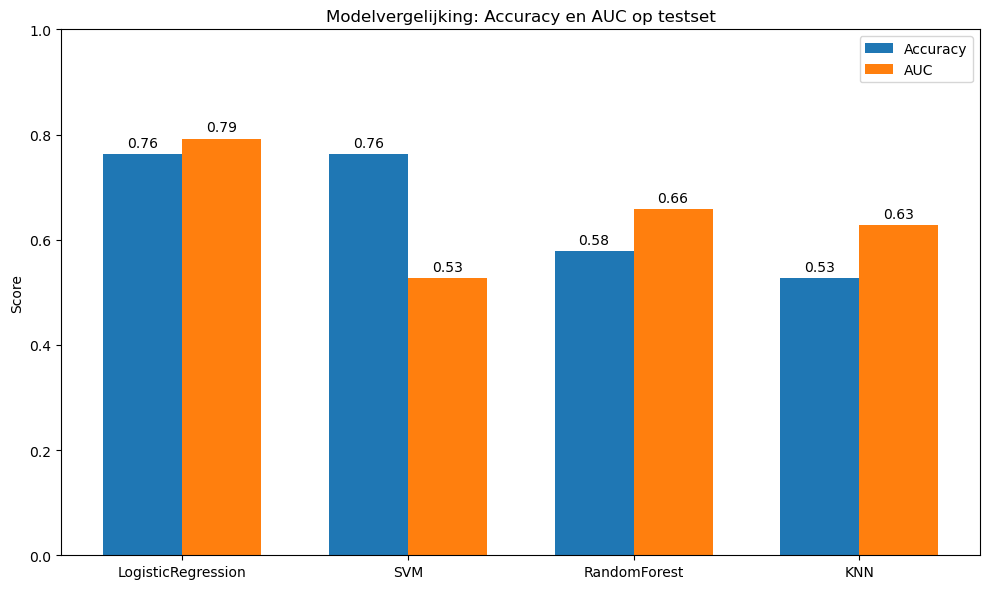

In [9]:
# Verzamel scores voor plot
model_names = []
accuracies = []
aucs = []

for name, res in results.items():
    model_names.append(name)
    accuracies.append(res['accuracy_test'])
    aucs.append(res['auc'] if res['auc'] is not None else 0)

# Plot maken
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy')
rects2 = ax.bar(x + width/2, aucs, width, label='AUC')

# Labels en styling
ax.set_ylabel('Score')
ax.set_title('Modelvergelijking: Accuracy en AUC op testset')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1)

# Scores boven de balken tonen
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.2f}", xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()


[LogisticRegression] AUC = 0.7922437673130194, model = <class 'sklearn.pipeline.Pipeline'>
[SVM] AUC = 0.5263157894736842, model = <class 'sklearn.pipeline.Pipeline'>
[RandomForest] AUC = 0.6578947368421053, model = <class 'sklearn.pipeline.Pipeline'>
[KNN] AUC = 0.6274238227146814, model = <class 'sklearn.pipeline.Pipeline'>


C:\Users\liann\AppData\Local\Temp\ipykernel_10196\1177931679.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


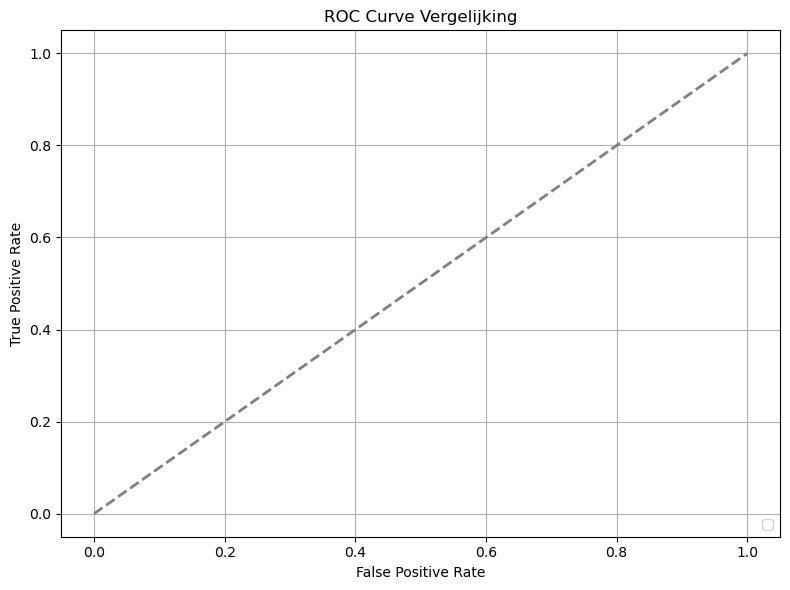

In [10]:
# === Gezamenlijke ROC-curve ===
plt.figure(figsize=(8, 6))
lw = 2
plt.plot([0, 1], [0, 1], linestyle='--', lw=lw, color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Vergelijking')

for name, res in results.items():
    model = res['model_object']
    auc_val = res['auc']
    print(f"[{name}] AUC = {auc_val}, model = {type(model)}")
    if auc_val is not None:
        try:
            y_proba = model.predict_proba(X_test)
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=lw, label=f'{name} (AUC = {roc_auc:.2f})')
        except:
            continue

plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Scaling 
##### First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers